<a href="https://colab.research.google.com/github/vijaybsbs/zomato_case_study_using_sql/blob/main/Zomato_Market_Analysis_%26_Business_Question_using_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Zomato Restaurant Market Analysis — SQL & EDA Case Study**

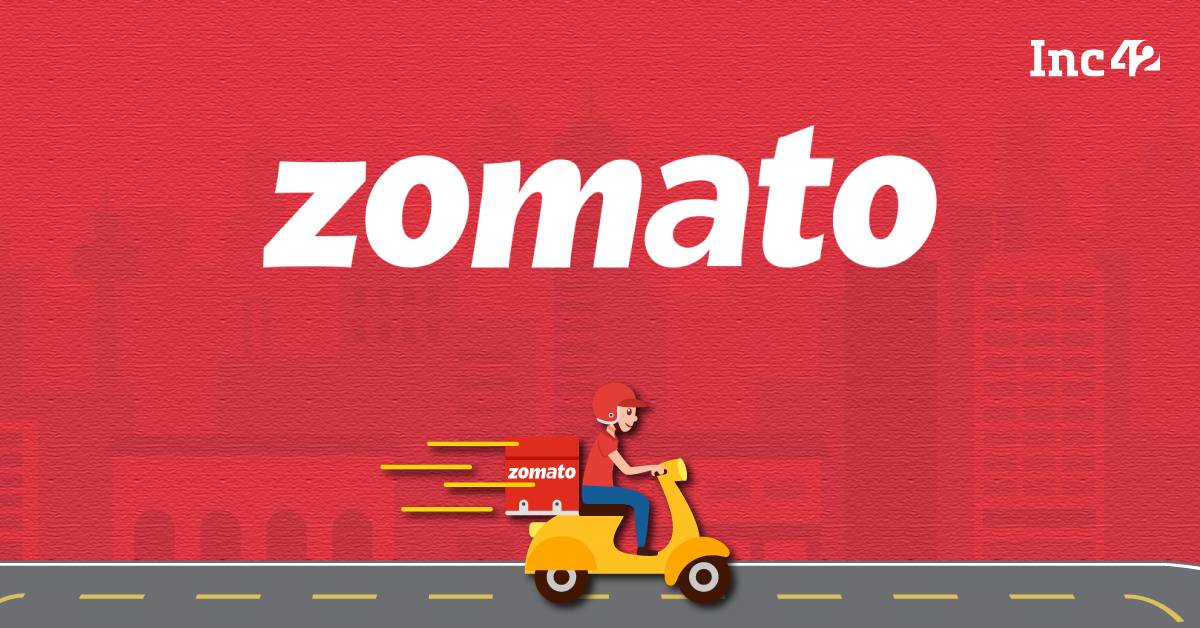

**Executive Summary**

This analysis evaluates 9,551 restaurant records across 15 countries and 141 cities. The dataset is heavily concentrated in India, accounting for 90.59% of records, with New Delhi representing the largest city market.

The analysis identifies a significant opportunity to improve restaurant quality and customer engagement, as 3,562 Indian restaurants fall into the "Needs Attention" segment while only 12 qualify as High Value Performers.

Online delivery adoption also varies significantly by city, suggesting opportunities for targeted restaurant onboarding and delivery expansion.

Based on these findings, recommendations include city-specific delivery expansion, value-for-money restaurant promotion, cuisine personalization and restaurant-performance improvement programs.

**Tools:** SQL (via SQLite, mirroring BigQuery Standard SQL syntax) · Python (pandas, seaborn, matplotlib)

**Coding approach:** Kept simple and close to the original notebook style using Pandas, SQLite and SQL queries.


**Business Objective**

Analyze restaurant pricing, customer engagement, online delivery adoption and restaurant performance to identify market opportunities and provide actionable recommendations for Zomato.

# **KPI Dashboard**

In [176]:
total_restaurants = len(df)
print("Total Restaurants:", total_restaurants)

total_countries = df["CountryName"].nunique()
print("Total Countries:", total_countries)

total_cities = df["City"].nunique()
print("Total Cities:", total_cities)

india_restaurants = len(df[df["CountryName"] == "India"])
print("India Restaurants:", india_restaurants)

india_share = (india_restaurants / total_restaurants) * 100
print("India Share: {:.2f}%".format(india_share))

zero_votes = len(df[df["Votes"] == 0])
print("Zero Votes:", zero_votes)

Total Restaurants: 9551
Total Countries: 15
Total Cities: 141
India Restaurants: 8652
India Share: 90.59%
Zero Votes: 1094


# **1. Importing Libraries & Data**

In [165]:
#importing Libraries

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams["font.size"] = 11
RED = "#CB202D" # Zomato brand red, used consistently across charts

In [3]:
df = pd.read_excel('Zomato.xlsx')
df.head()

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating,CountryName
0,6317637,Le Petit Souffle,162,Makati City,Third Floor| Century City Mall| Kalayaan Avenu...,Century City Mall| Poblacion| Makati City,Century City Mall| Poblacion| Makati City| Mak...,French| Japanese| Desserts,Botswana Pula(P),Yes,No,No,No,3,314,1100,4.8,Philippines
1,6304287,Izakaya Kikufuji,162,Makati City,Little Tokyo| 2277 Chino Roces Avenue| Legaspi...,Little Tokyo| Legaspi Village| Makati City,Little Tokyo| Legaspi Village| Makati City| Ma...,Japanese,Botswana Pula(P),Yes,No,No,No,3,591,1200,4.5,Philippines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,Edsa Shangri-La| 1 Garden Way| Ortigas| Mandal...,Edsa Shangri-La| Ortigas| Mandaluyong City,Edsa Shangri-La| Ortigas| Mandaluyong City| Ma...,Seafood| Asian| Filipino| Indian,Botswana Pula(P),Yes,No,No,No,4,270,4000,4.4,Philippines
3,6318506,Ooma,162,Mandaluyong City,Third Floor| Mega Fashion Hall| SM Megamall| O...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Sushi,Botswana Pula(P),No,No,No,No,4,365,1500,4.9,Philippines
4,6314302,Sambo Kojin,162,Mandaluyong City,Third Floor| Mega Atrium| SM Megamall| Ortigas...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Korean,Botswana Pula(P),Yes,No,No,No,4,229,1500,4.8,Philippines


# **2. Exploratory Data Analysis**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RestaurantID          9551 non-null   int64  
 1   RestaurantName        9551 non-null   object 
 2   CountryCode           9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   LocalityVerbose       9551 non-null   object 
 7   Cuisines              9542 non-null   object 
 8   Currency              9551 non-null   object 
 9   Has_Table_booking     9551 non-null   object 
 10  Has_Online_delivery   9551 non-null   object 
 11  Is_delivering_now     9551 non-null   object 
 12  Switch_to_order_menu  9551 non-null   object 
 13  Price_range           9551 non-null   int64  
 14  Votes                 9551 non-null   int64  
 15  Average_Cost_for_two 

In [5]:
df.nunique()

,0
RestaurantID,9551
RestaurantName,7446
CountryCode,15
City,141
Address,8918
Locality,1208
LocalityVerbose,1265
Cuisines,1825
Currency,12
Has_Table_booking,2


**Insights**

1. The dataset contains `9551 restaurants` across 18 columns with very few missing values in `Cuisines`
2. The dataset covers `15 countries` and `141 cities`

In [6]:
df.duplicated().value_counts()

,count
False,9551


In [7]:
df.describe()

,RestaurantID,CountryCode,Price_range,Votes,Average_Cost_for_two,Rating
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,1.804837,156.909748,1199.210763,2.891268
std,8.791521e+06,56.750546,0.905609,430.169145,16121.183073,1.128845
min,5.300000e+01,1.000000,1.000000,0.000000,0.000000,1.000000
25%,3.019625e+05,1.000000,1.000000,5.000000,250.000000,2.500000
50%,6.004089e+06,1.000000,2.000000,31.000000,400.000000,3.200000
75%,1.835229e+07,1.000000,2.000000,131.000000,700.000000,3.700000
max,1.850065e+07,216.000000,4.000000,10934.000000,800000.000000,4.900000


**Insights**

1. There are `no duplicates` in the dataset, so each record can be treated as a unique observations for further analysis
2. The `average number of votes` is around *157*, while the median is only *31*, indicating that customer votes are **highly skewed**. A small number of restaurants receive significantly more votes than most restaurants.
3. The `average cost` is significantly higher than the median, mainly because of a few extremely high-cost restaurants. This indicates that **Average_Cost_for_two** contains significant outliers.
4. Restaurant ratings range from `1.0 to 4.9`, with a median rating of **3.2**. This indicates a wide variation in restaurant quality. perception across the dataset.

In [73]:
print("Rating == 0 count:", (df["Rating"] == 0).sum())
print("Rating is null count:", df["Rating"].isna().sum())
print()

print("Voting == 0 count:", (df["Votes"] == 0).sum())
print("Voting is null count:", df["Votes"].isna().sum())
print()

effectively_unrated = df[(df["Rating"] <=1.0) & (df["Votes"] <= 3)]
print("Low engagement restaurants with very low ratings:", len(effectively_unrated))

Rating == 0 count: 0
Rating is null count: 0

Voting == 0 count: 1094
Voting is null count: 0

Low engagement restaurants with very low ratings: 2148


**Insights**

1. There are `no zero and missing ratings`. However, may restaurants have very low ratings and very few votes, which should be considered when evaluation restaurant performance
2. `1094 restaurants have zero votes`, indicating that a noticeable number of restaurants have no recorded customer engagement.
3. `2148 restaurants have a rating of 1.0 or below and no more than 3 votes`, indicating a group of restaurants with very low customer engagement and poor recorded ratings.

In [37]:
country_currency = (df.groupby("CountryName")["Currency"].value_counts())

result = pd.DataFrame({
"Count:": country_currency,
"Percentage:": country_currency.apply(lambda x: x / country_currency.sum()*100).round(2).astype(str) + "%"
})
print(result.sort_values(by="Count:", ascending=False))

                                             Count: Percentage:
CountryName          Currency                                  
India                Indian Rupees(Rs.)        8652      90.59%
United States        Dollar($)                  434       4.54%
England              Pounds(?)                   80       0.84%
South Africa         Rand(R)                     60       0.63%
United Arab Emirates Emirati Diram(AED)          60       0.63%
Brazil               Brazilian Real(R$)          60       0.63%
New Zealand          NewZealand($)               40       0.42%
Turkey               Turkish Lira(TL)            34       0.36%
Australia            Dollar($)                   24       0.25%
Philippines          Botswana Pula(P)            22       0.23%
Indonesia            Indonesian Rupiah(IDR)      21       0.22%
Singapore            Dollar($)                   20       0.21%
Qatar                Qatari Rial(QR)             20       0.21%
Sri Lanka            Sri Lankan Rupee(LK

**Insights**

1. `India accounts for 90.59% of all records`, making it the dominant market in this dataset. Therefore, overall findings are strongly influenced by the Indian restaurant market.

**Insight - Mixed Currencies in `Average_Cost_for_two`**

The `Average_Cost_for_two` column contains restaurant costs reported in **different currencies** acorss countries. Therefore, directly comparing or calculating the overall average cost is misleading because the values are not expressed in a common currency. Cost comparison should be performed **within each country** or after converting all values to a common currency.

Cost-based questions were scoped to `CountryName = "India"`, since its 90.59% of the data and the rest would otherwise skew results with currency arifacts.

**Restaurant Distribution**

In [75]:
top10_restaurants = df.groupby("CountryName")["RestaurantName"].count().sort_values(ascending=False)
top10_restaurants.head(10)

,RestaurantName
CountryName,
India,8652
United States,434
England,80
South Africa,60
United Arab Emirates,60
Brazil,60
New Zealand,40
Turkey,34
Australia,24


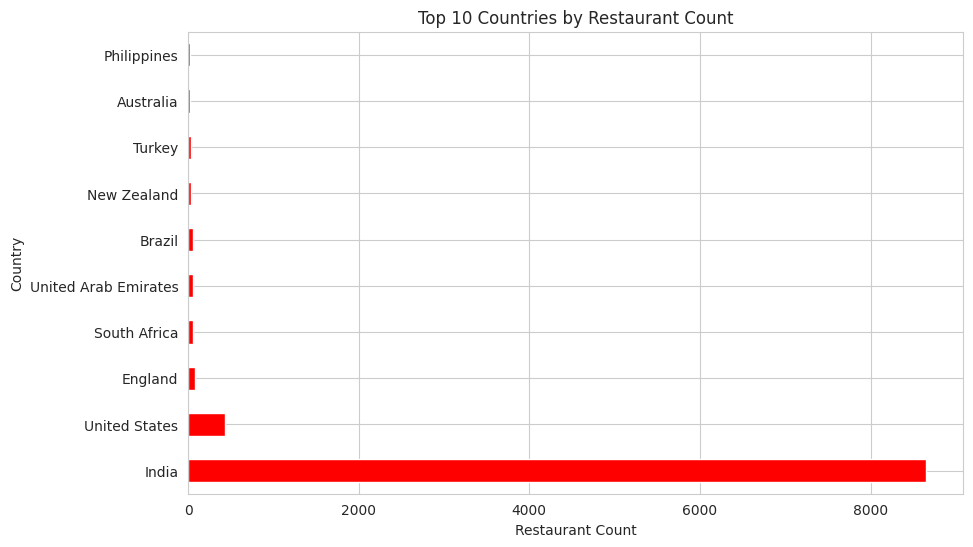

In [83]:
top10_restaurants.head(10).plot(kind = "barh", figsize = (10,6), color = "RED")
plt.title("Top 10 Countries by Restaurant Count")
plt.xlabel("Restaurant Count")
plt.ylabel("Country")
plt.show()

**Insight**

`India` has by far the highest number of restaurants in the dataset(8,652), followed by US(434). This shows that the dataset is heavily concentrated in India, so most of the analysis will be driven by the Indian restaurant market.

In [86]:
top10_cities = df.groupby("City")["RestaurantName"].count().sort_values(ascending=False)
top10_cities.head(10)

,RestaurantName
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Lucknow,21
Guwahati,21
Ahmedabad,21


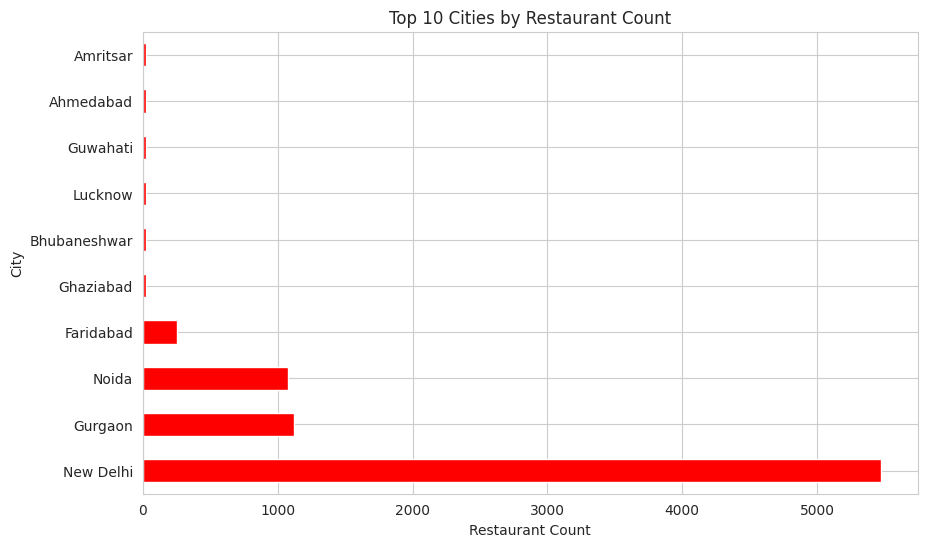

In [87]:
top10_cities.head(10).plot(kind= "barh", figsize=(10,6), color = "RED")
plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("Restaurant Count")
plt.ylabel("City")
plt.show()

**Insight**

`New Delhi` has the highest number of restaurants by a large margin(5,473), followed by Gurgaon and Noida. This shows that the dataset is heavily concentrated in the New Delhi region.

**Rating and Pricing Analysis**

In [110]:
rating = df["Rating"]

df["rating_band"] = "4.5 - 5"

df.loc[rating.isna() | (rating == 0), "rating_band"] = "Not Rated"
df.loc[(rating > 0) & (rating < 2), "rating_band"] = "Below 2"
df.loc[(rating >= 2) & (rating < 3), "rating_band"] = "2 - 2.9"
df.loc[(rating >= 3) & (rating < 4), "rating_band"] = "3 - 3.9"
df.loc[(rating >= 4) & (rating < 4.5), "rating_band"] = "4 - 4.4"

result = (
    df.groupby("rating_band")
      .size()
      .sort_values(ascending=False)
)

display(result)

,0
rating_band,
3 - 3.9,4590
Below 2,2151
2 - 2.9,1430
4 - 4.4,1079
4.5 - 5,301


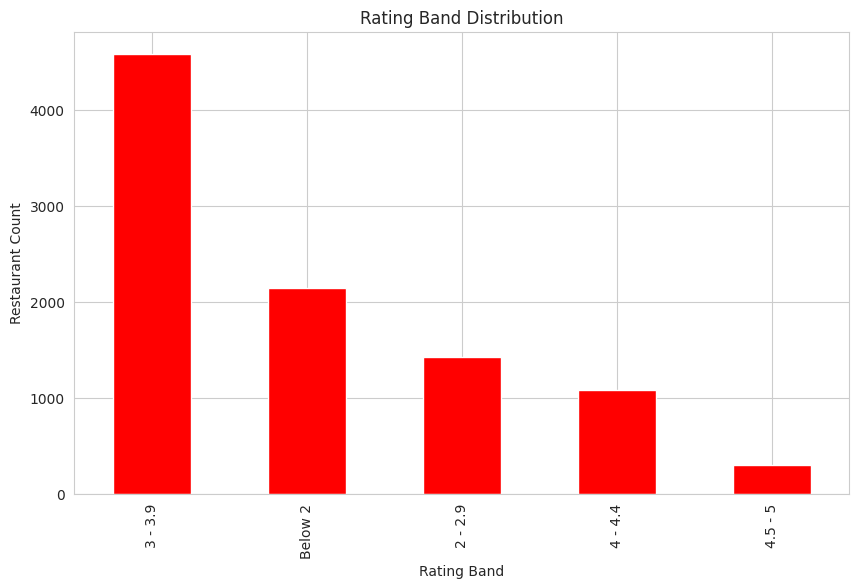

In [107]:
result.plot(kind = "bar", figsize = (10,6), color = "RED")
plt.title("Rating Band Distribution")
plt.xlabel("Rating Band")
plt.ylabel("Restaurant Count")
plt.show()

**Insight**
Most restaurants fall in the `3-3.9 rating band`, followed by `below 2` and `2-2.9`. Only a small number of restaurants have ratings above `4.5`, showing that highly rated restaurants are relatively rare in the dataset

In [116]:
india_df = df[df["CountryName"] == "India"]

price_result = india_df.groupby("Price_range").agg(
    restaurant_count=("RestaurantName", "count"),
    average_rating=("Rating", "mean"),
    average_votes=("Votes", "mean"),
    average_cost=("Average_Cost_for_two", "mean")
)

price_result = price_result.round({
    "average_rating": 2,
    "average_votes": 0,
    "average_cost": 2
})

price_result = price_result.reset_index()

price_result = price_result.sort_values("Price_range")

display(price_result)

,Price_range,restaurant_count,average_rating,average_votes,average_cost
0,1,4295,2.33,36.0,284.38
1,2,2858,2.99,133.0,620.13
2,3,1111,3.60,444.0,1257.88
3,4,388,3.66,404.0,2582.86


**Insight**

Price range 1 has the highest number of restaurants (4295) and the lowest average cost(284) but also has the lowest average rating(2.33). As the price range increases, the average rating and customer votes generally increase, while the average cost rises significantly. This suggests that **higher-priced restaurants tend to receive better ratings due its stronger customer engagement** in the dataset

**Correlation Analysis**

In [118]:
correlation = df[["Rating","Votes", "Average_Cost_for_two", "Price_range"]].corr()
correlation.round(2)

,Rating,Votes,Average_Cost_for_two,Price_range
Rating,1.00,0.35,0.06,0.46
Votes,0.35,1.00,0.07,0.31
Average_Cost_for_two,0.06,0.07,1.00,0.08
Price_range,0.46,0.31,0.08,1.00


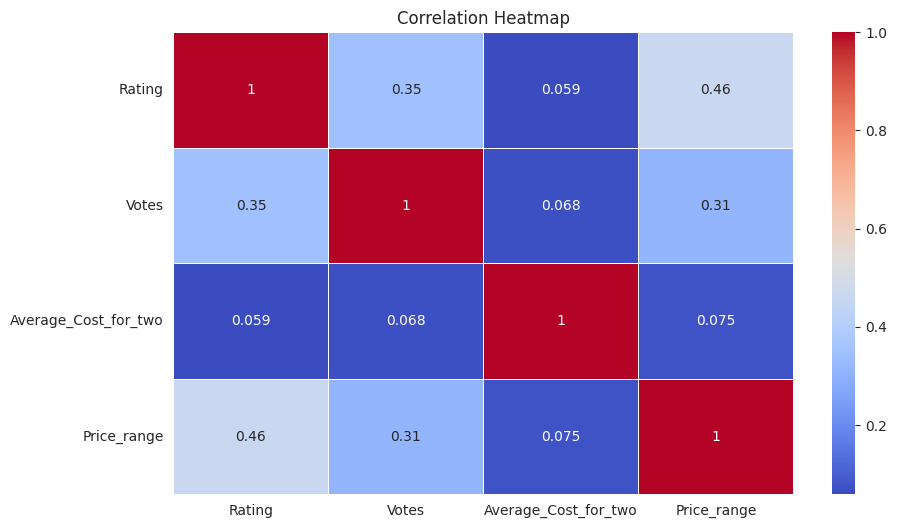

In [119]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Insight**
Rating has a moderate positive relationship with `Price Range (0.46)` and `Votes (0.35)`. This suggests that higher-priced restaurants tend to have slightly higher ratings and customer engagement in the dataset. However, correlation does not imply that price or engagement causes higher ratings.

`Average Cost for Two has very weak correlation` with Rating (0.059) and Votes (0.068), indicating that cost alone does not strongly influence ratings or customer votes.

**Business Questions using SQL**

In [127]:
conn = sqlite3.connect(":memory:")

df.to_sql("zomato", conn, if_exists="replace", index=False)

def run(query, label=None):

    if label:
        print(f"=== {label} ===")

    result = pd.read_sql(query, conn)

    return result


**Q1 — Most Expensive Restaurants**

Which 10 restaurants in India have the highest average cost for two, and what are their cities and price ranges?

In [128]:
q1 = """
select RestaurantName, City, Average_Cost_for_two, Price_range
from zomato
where CountryName = 'India'
order by Average_Cost_for_two desc
limit 10
"""
run(q1, "Q1 - Top 10 most expensive restaurants (India)")


=== Q1 - Top 10 most expensive restaurants (India) ===


,RestaurantName,City,Average_Cost_for_two,Price_range
0,Orient Express - Taj Palace Hotel,New Delhi,8000,4
1,Tian - Asian Cuisine Studio - ITC Maurya,New Delhi,7000,4
2,Bukhara - ITC Maurya,New Delhi,6500,4
3,Nostalgia at 1911 Brasserie - The Imperial,New Delhi,6000,4
4,1911 - The Imperial,New Delhi,6000,4
5,The Spice Route - The Imperial,New Delhi,6000,4
6,Wasabi by Morimoto - The Taj Mahal Hotel,New Delhi,6000,4
7,MEGU - The Leela Palace,New Delhi,5500,4
8,House of Ming - The Taj Mahal Hotel,New Delhi,5500,4
9,24/7 Restaurant - The Lalit New Delhi,New Delhi,5100,4


**Q2 — Zero/Missing Ratings or Votes**

Which restaurants have zero votes or missing rating/vote values, and how many such restaurants are there?

In [157]:
q2 = """
select RestaurantName, City, Rating, Votes
from zomato
where Rating = 0
   or Votes = 0
   or Rating is NULL
   or Votes is NULL
   limit 10

"""
run(q2, "Q2 - Zero/null rating or votes")

=== Q2 - Zero/null rating or votes ===


,RestaurantName,City,Rating,Votes
0,Cantinho da Gula,S?o Paulo,1.0,0
1,The Chaiwalas,Faridabad,1.0,0
2,Fusion Food Corner,Faridabad,1.0,0
3,Punjabi Rasoi,Faridabad,1.0,0
4,Baskin Robbin,Faridabad,1.0,0
5,Angaar,Faridabad,1.0,0
6,TcozY,Faridabad,1.0,0
7,The Retriever,Faridabad,1.0,0
8,Chill 'N Grill,Faridabad,1.0,0
9,Punjabi Restaurant,Faridabad,1.0,0


In [158]:
q2a = """
select count(*) as restaurants_with_zero_votes
from zomato
where Rating = 0 or Votes = 0 or Rating is NULL or Votes is NULL
"""
run(q2a, "Q2a - Zero/null rating or votes")


=== Q2a - Zero/null rating or votes ===


,restaurants_with_zero_votes
0,1094


**Q3 — Indian Restaurants Without Online Delivery**

How many restaurants in India serve Indian cuisine but do not offer online delivery, and which restaurants are they?

In [159]:
q3 = """
select RestaurantName, Cuisines, CountryName, Has_Online_delivery
from zomato
where CountryName = 'India'
  and lower(Cuisines) like '%indian%'
  and Has_Online_delivery = 'No'
  """
run(q3, "Q3 - Indian restaurants serving Indian cuisine with no online delivery")


=== Q3 - Indian restaurants serving Indian cuisine with no online delivery ===


,RestaurantName,Cuisines,CountryName,Has_Online_delivery
0,Jahanpanah,North Indian| Mughlai,India,No
1,Rangrezz Restaurant,North Indian| Mughlai,India,No
2,Time2Eat - Mama Chicken,North Indian,India,No
3,Pinch Of Spice,North Indian| Chinese| Mughlai,India,No
4,MoMo Cafe,North Indian| European,India,No
...,...,...,...,...
3017,My Restaurant,Andhra| North Indian| Chinese,India,No
3018,Six Degrees,South Indian| Chinese| Continental| Italian| N...,India,No
3019,D Cabana,Continental| Seafood| Chinese| North Indian| B...,India,No
3020,Kaloreez,Cafe| North Indian| Chinese,India,No


In [160]:
q3a = """
select count(*) as indian_restaurants_without_online_delivery
from zomato
where CountryName = 'India'
  and lower(Cuisines) like '%indian%'
  and Has_Online_delivery = 'No'
  limit 10
"""
run(q3a, "Q3a - Indian restaurants serving Indian cuisine with no online delivery")


=== Q3a - Indian restaurants serving Indian cuisine with no online delivery ===


,indian_restaurants_without_online_delivery
0,3022


**Q4 — High-Performing Budget Restaurants**

Which restaurants in India offer the best combination of high customer ratings, strong customer engagement and affordability, defined as a rating of at least 4.5, more than 500 votes, and an average cost for two below ₹800?

In [132]:
q4 = """
select RestaurantName, Rating, Votes, Average_Cost_for_two
from zomato
where CountryName = 'India' and rating >= 4.5 and votes > 500 and Average_Cost_for_two < 800
order by rating desc, Average_Cost_for_two asc
"""
run(q4, "Q4 - High-performing, budget-friendly (India)")


=== Q4 - High-performing, budget-friendly (India) ===


,RestaurantName,Rating,Votes,Average_Cost_for_two
0,Naturals Ice Cream,4.9,2620,150
1,Grandson of Tunday Kababi,4.9,1057,300
2,Con?u,4.8,1023,600
3,Echoes Satyaniketan,4.7,1563,600
4,Tapri Central,4.7,1469,750
5,Fusilli Reasons,4.6,1510,350
6,Onesta,4.6,781,600
7,Onesta,4.6,627,600
8,Natural Ice Cream,4.5,665,150
9,Kuremal Mohan Lal Kulfi Wale,4.5,545,200


**Q5 — Online Delivery Adoption**

Among cities with at least 10 listed restaurants, which five have the highest online-delivery adoption rate?

In [133]:
q5 = """
select City,
    sum(online_delivery_flag) as online_delivery_count,
    count(online_delivery_flag) as total_restaurants,
    round(sum(online_delivery_flag) * 100.0 / count(online_delivery_flag), 2) as online_delivery_pct
from (
  select City, case when Has_Online_delivery = 'Yes' then 1 else 0 end as online_delivery_flag
  from zomato
) as x
group by City
having count(online_delivery_flag) >= 10
order by online_delivery_pct desc
limit 5
"""
run(q5, "Q5 - Top 5 cities by online delivery %")


=== Q5 - Top 5 cities by online delivery % ===


,City,online_delivery_count,total_restaurants,online_delivery_pct
0,Chennai,13,20,65.00
1,Sharjah,11,20,55.00
2,Abu Dhabi,11,20,55.00
3,Ahmedabad,11,21,52.38
4,Nagpur,10,20,50.00


**Q6 — Delivery Without Table Booking**

Which two cities have the highest number of restaurants that are currently delivering but do not offer table booking?

In [134]:
q6 = """
select City, count(RestaurantID) as count_of_restaurants
from zomato
where is_delivering_now = 'Yes' and Has_Table_booking = 'No'
group by City
order by count_of_restaurants desc
limit 2
"""
run(q6, "Q6 - Top 2 cities, delivers now & no table booking")


=== Q6 - Top 2 cities, delivers now & no table booking ===


,City,count_of_restaurants
0,New Delhi,15
1,Gurgaon,12


**Q7 — Cuisine Popularity**


- For each city, which cuisine combination has accumulated the highest total number of votes?


- Which city-cuisine combination has the highest total number of votes across the entire dataset?

In [156]:
q7 = """
WITH CityCuisineVotes AS (
  SELECT City, Cuisines, SUM(Votes) AS total_votes
  FROM zomato GROUP BY City, Cuisines
),
RankedCuisines AS (
  SELECT City, Cuisines, total_votes,
    ROW_NUMBER() OVER (PARTITION BY City ORDER BY total_votes DESC) AS rn
  FROM CityCuisineVotes
)
SELECT City, Cuisines, total_votes FROM RankedCuisines WHERE rn = 1
ORDER BY total_votes DESC
"""
run(q7, "Q7 - Top cuisine by votes per city (top 10 shown)")


=== Q7 - Top cuisine by votes per city (top 10 shown) ===


,City,Cuisines,total_votes
0,New Delhi,North Indian| Mughlai,27951
1,Bangalore,Italian| American| Pizza,10934
2,Gurgaon,North Indian| Mughlai,9694
3,Noida,North Indian| Mughlai,7832
4,Mumbai,Pizza,7807
...,...,...,...
136,Mayfield,Asian,11
137,Miller,None,11
138,Potrero,American| BBQ| Burger,9
139,Cochrane,Asian| Japanese,6


In [136]:
q7_best = """
WITH CityCuisineVotes AS (
  SELECT City, Cuisines, SUM(Votes) AS total_votes
  FROM zomato GROUP BY City, Cuisines
)
SELECT City, Cuisines, total_votes FROM CityCuisineVotes
ORDER BY total_votes DESC LIMIT 1
"""
run(q7_best, "Q7 - single best city-cuisine combination overall")

=== Q7 - single best city-cuisine combination overall ===


,City,Cuisines,total_votes
0,New Delhi,North Indian| Mughlai,27951


**Q8 — City Dining Cost**

Among Indian cities, which cities have an average dining cost for two above the overall Indian average, and which Indian city has the lowest average dining cost for two?

In [137]:
q8 = """
select * from (
  select city, round(avg(Average_Cost_for_two), 2) as city_cost
  from zomato
  where CountryName = 'India'
  group by city
) X
where X.city_cost > (
  select round(avg(Average_Cost_for_two), 2) from zomato where CountryName = 'India'
)
order by X.city_cost desc
"""
run(q8 + "limit 10", "Q8 - Cities above national avg cost for two (India)")


=== Q8 - Cities above national avg cost for two (India) ===


,city,city_cost
0,Panchkula,2000.00
1,Hyderabad,1361.11
2,Pune,1337.50
3,Jaipur,1310.00
4,Kolkata,1272.50
5,Bangalore,1232.50
6,Goa,1175.00
7,Ludhiana,1160.00
8,Chennai,1085.00
9,Mumbai,1072.50


In [138]:
q8_low = """
select city, round(avg(Average_Cost_for_two), 2) as city_cost
from zomato
where CountryName = 'India'
group by city
order by city_cost asc
limit 1
"""
run(q8_low, "Q8 - Cheapest city (India)")

=== Q8 - Cheapest city (India) ===


,City,city_cost
0,Faridabad,447.61


**Restaurant Segmentation**

These thresholds are project-defined assumptions for segmentation and are not official Zomato classifications

In [140]:
q9 = """
select
    RestaurantName,
    City,
    Rating,
    Votes,
    Average_Cost_for_two,
    case
        when Rating >= 4.5
             and Votes > 500
             and Average_Cost_for_two < 800
            then 'High Value Performer'

        when Rating >= 4
             and Votes >= 200
            then 'Strong Performer'

        when Rating >= 3
            then 'Average Performer'

        else 'Needs Attention'
    end as restaurant_segment
from zomato
where CountryName = 'India'
order by Rating desc, Votes desc
"""

run(q9, "Restaurant Performance Segmentation")


=== Restaurant Performance Segmentation ===


,RestaurantName,City,Rating,Votes,Average_Cost_for_two,restaurant_segment
0,Barbeque Nation,Kolkata,4.9,5966,1600,Strong Performer
1,AB's - Absolute Barbecues,Hyderabad,4.9,5434,1500,Strong Performer
2,Mirchi And Mime,Mumbai,4.9,3244,1500,Strong Performer
3,Naturals Ice Cream,New Delhi,4.9,2620,150,High Value Performer
4,Indian Accent - The Manor,New Delhi,4.9,1934,4000,Strong Performer
...,...,...,...,...,...,...
8647,6 Packs Momos,Noida,1.0,0,300,Needs Attention
8648,Cafe' Wow,Noida,1.0,0,200,Needs Attention
8649,Chef's Basket Pop Up Caf?,Noida,1.0,0,200,Needs Attention
8650,The Hangout-Deli,Noida,1.0,0,1000,Needs Attention


In [141]:
q9a = """
select
    case
        when Rating >= 4.5
             and Votes > 500
             and Average_Cost_for_two < 800
            then 'High Value Performer'

        when Rating >= 4
             and Votes >= 200
            then 'Strong Performer'

        when Rating >= 3
            then 'Average Performer'

        else 'Needs Attention'
    end as restaurant_segment,
    count(*) as restaurant_count,
    round(avg(Rating),2) as average_rating,
    round(avg(Votes),0) as average_votes,
    round(avg(Average_Cost_for_two),2) as average_cost
from zomato
where CountryName = 'India'
group by restaurant_segment
order by restaurant_count desc
"""

run(q9a, "Restaurant Segment Summary")


=== Restaurant Segment Summary ===


,restaurant_segment,restaurant_count,average_rating,average_votes,average_cost
0,Average Performer,4581,3.46,131.0,713.63
1,Needs Attention,3562,1.68,19.0,417.77
2,Strong Performer,497,4.25,1019.0,1269.01
3,High Value Performer,12,4.65,1102.0,458.33


**Insight**

Most restaurants are classified as Average Performers (4,581), while 3,562 restaurants fall under Needs Attention with low ratings and votes. Only 497 are Strong Performers, and just 12 qualify as High Value Performers. This indicates that there is a `large opportunity to improve restaurant quality and customer engagement`, while the `High Value Performer segment is very small`.

**Overall Business Strategy**

Zomato should focus on improving `restaurant quality and customer engagement` while expanding online delivery in high-potential markets. `New Delhi should remain a key market` due to its large restaurant base, while cities with strong restaurant presence and lower delivery adoption can be targeted for expansion.

Zomato can further improve customer discovery through `city-specific cuisine recommendations, price-segment strategies and value-for-money restaurant promotions`.